In [ ]:
import torch
import open_clip
from PIL import Image
import os
from tqdm.auto import tqdm

/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIR = '../data/sticker_suggest/'
def filepath(filename):
    return os.path.join(DATA_DIR, filename) 

In [3]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'mps'

In [4]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14", pretrained="openai")

/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [5]:
model.to(device)

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1024,), eps=1e-05, elementwi

In [5]:
tokenizer = open_clip.get_tokenizer("ViT-L-14")

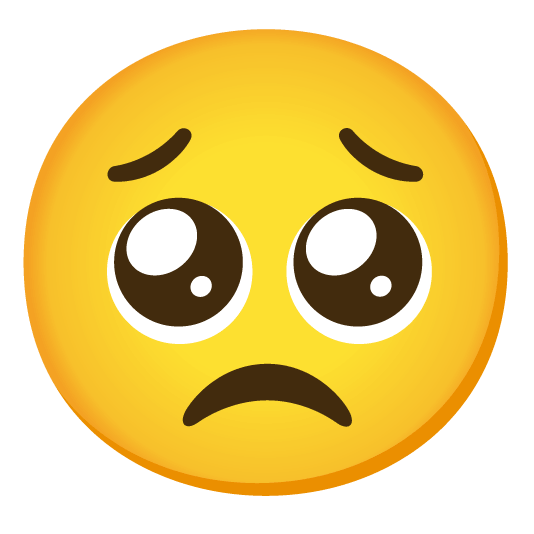

torch.Size([1, 3, 224, 224]) RGBA


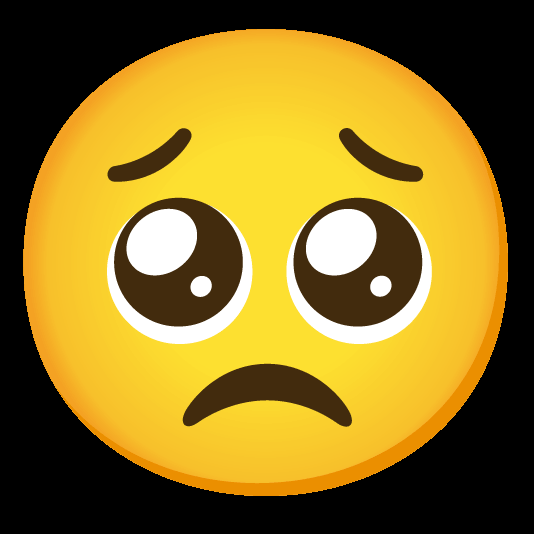

torch.Size([1, 3, 224, 224])
Cosine similarity between original and RGB image features: 0.989798903465271
Cosine similarity after normalization: 0.9897990226745605
Cosine similarity between image and text features: 0.26232123374938965
Cosine similarity between RGB image and text features: 0.25966396927833557


In [23]:
sample_img = Image.open(filepath("5764992584032194316.png"))
display(sample_img)
sample_img_clip = preprocess(sample_img).unsqueeze(0).to(device)
print(sample_img_clip.shape, sample_img.mode)

rgb_sample_img = sample_img.convert("RGB")
display(rgb_sample_img)
rgb_sample_img_clip = preprocess(rgb_sample_img).unsqueeze(0).to(device)
print(rgb_sample_img_clip.shape)

text_tokens = tokenizer(["sad emoji sticker"]).to(device)

with torch.no_grad():
    features = model.encode_image(sample_img_clip)
    rgb_features = model.encode_image(rgb_sample_img_clip)
    text_features = model.encode_text(text_tokens)

similarity = torch.cosine_similarity(features, rgb_features)
print(f"Cosine similarity between original and RGB image features: {similarity.item()}")

features /= features.norm(dim=-1, keepdim=True)
rgb_features /= rgb_features.norm(dim=-1, keepdim=True)
similarity = torch.cosine_similarity(features, rgb_features)
print(f"Cosine similarity after normalization: {similarity.item()}")

text_features /= text_features.norm(dim=-1, keepdim=True)
similarity = torch.cosine_similarity(features, text_features)
print(f"Cosine similarity between image and text features: {similarity.item()}")
print(f"Cosine similarity between RGB image and text features: {torch.cosine_similarity(rgb_features, text_features).item()}")

In [6]:
image_paths = [
    filepath(f) for f in os.listdir(DATA_DIR)
]

In [32]:
def rgba_to_white_bg(img: Image.Image) -> Image.Image:
    img = img.convert("RGBA")
    bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
    out = Image.alpha_composite(bg, img)
    return out.convert("RGB")

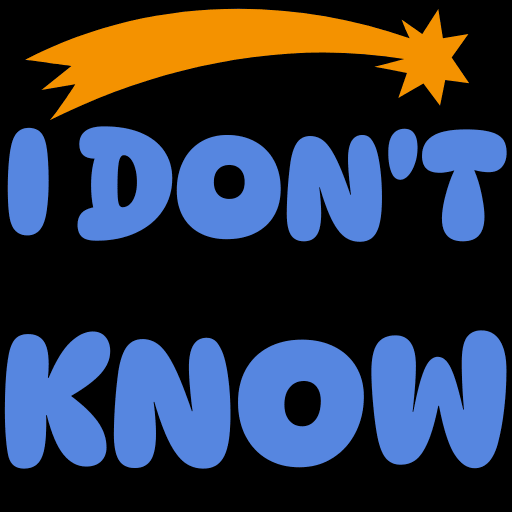

''


In [34]:
path = filepath("5395511541288155738.png")
img = Image.open(path).convert("RGB")
display(img)

text = pytesseract.image_to_string(img, lang="eng")
print(f"'{text}'")

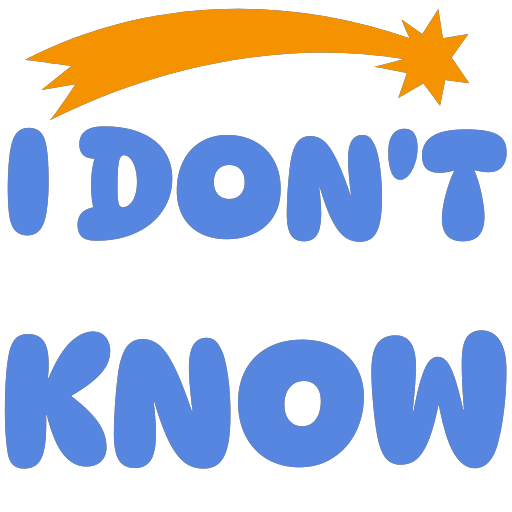

''


In [35]:
img = rgba_to_white_bg(Image.open(path))
display(img)

text = pytesseract.image_to_string(img, lang="eng")
print(f"'{text}'")

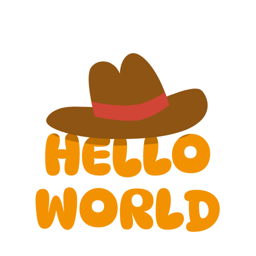

'as
'


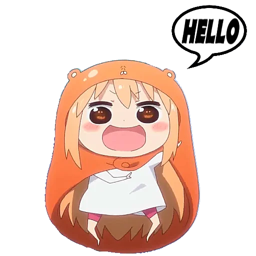

'GIES, \

//s_s))\

| | oy)
| w= |
'


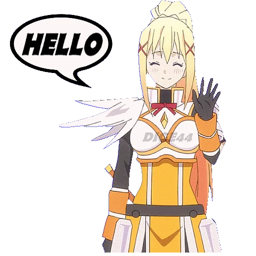

'DANN
'


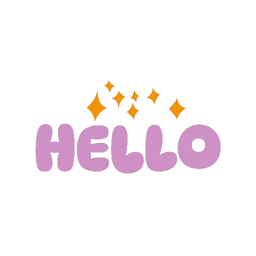

'$tite
HELLO
'


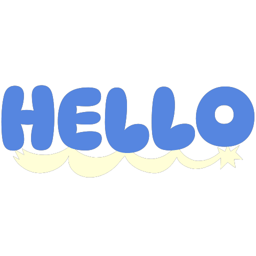

'HELLO
'


In [ ]:
from PIL import Image, ImageOps, ImageFilter
import pytesseract

text_images = [
    "../data/sticker_suggest/6224412105970288629.png",
    "../data/sticker_suggest/202331403893872726.png",
    "../data/sticker_suggest/5929419849271877741.png",
    "../data/sticker_suggest/6021866645201361172.png",
    "../data/sticker_suggest/6332410106600231736.png",
]


import cv2
import numpy as np
from PIL import Image

def preprocess_for_ocr(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # strong threshold
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

    return thresh

for path in text_images:
    img = Image.open(path)
    img = rgba_to_white_bg(img)
    img = img.resize((img.width // 2, img.height // 2))
    # img = preprocess_for_ocr(path)
    display(img)
    text = pytesseract.image_to_string(img, config="--psm 6 --oem 3", lang="eng")
    print(f"'{text}'")

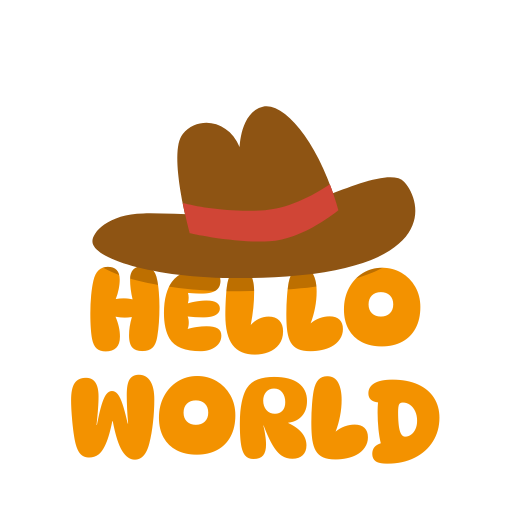

Hjeblo 0.46556603955481873
worLD 0.37907948951182735


/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


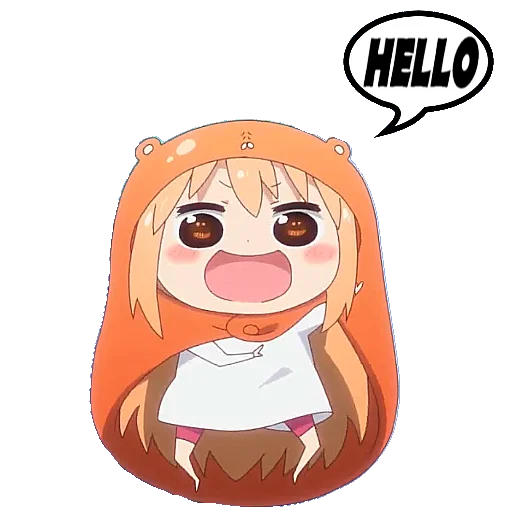

HiLLo 0.48258849617335337


/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


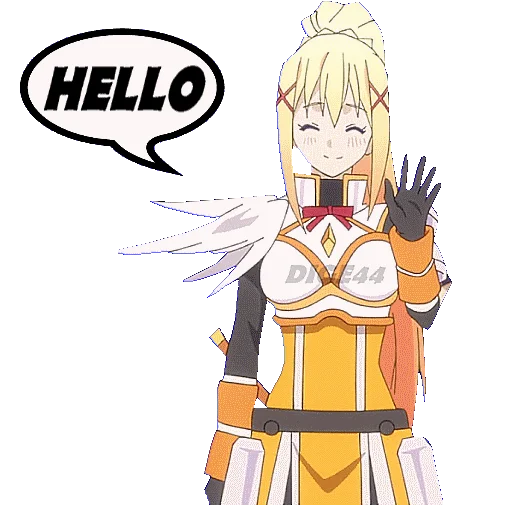

HELLO 0.9980478621612728


/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


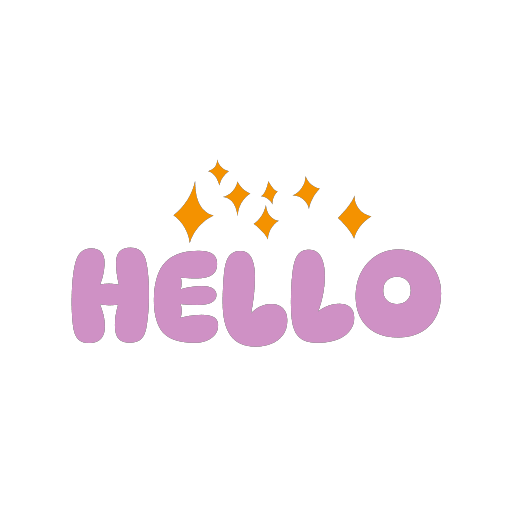

Hello 0.6969411718298251


/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


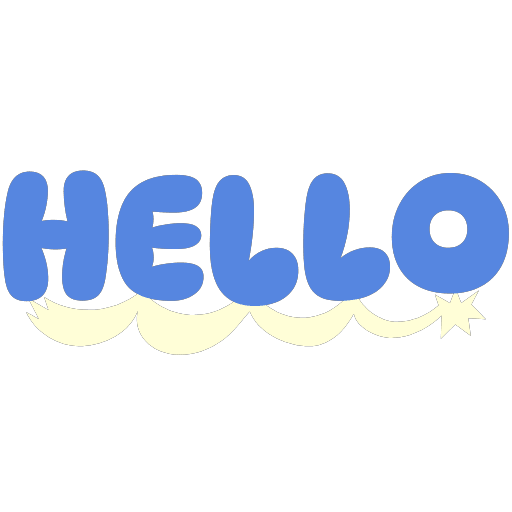

/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Hello 0.5081071033369321


In [64]:
import easyocr

reader = easyocr.Reader(['en'])

for path in text_images:
    img = Image.open(path)
    img = rgba_to_white_bg(img)
    # img = img.resize((img.width // 2, img.height // 2))
    display(img)
    result = reader.readtext(path)
    for bbox, text, conf in result:
        print(text, conf)

In [7]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore", message=".*pin_memory.*")

In [9]:
import easyocr

reader = easyocr.Reader(['en'])

def ocr(n=None):
    rows = []
    for path in tqdm(image_paths):
        try:
            result = reader.readtext(path)

            texts = [r[1] for r in result]
            confs = [r[2] for r in result]

            full_text = " ".join(texts).strip()
            avg_conf = sum(confs)/len(confs) if confs else 0

            rows.append({
                "path": path,
                "text": full_text,
                "has_text": len(full_text) > 0,
                "n_tokens": len(full_text),
                "avg_conf": avg_conf
            })

        except Exception as e:
            rows.append({
                "path": path,
                "text": "",
                "has_text": False,
                "n_tokens": 0,
                "avg_conf": 0
            })

        if n and len(rows) >= n: break
    return rows

In [87]:
rows = ocr(300)
df = pd.DataFrame(rows)
df.head()

  3%|▎         | 299/9848 [00:16<08:40, 18.35it/s]


,path,text,has_text,n_tokens,avg_conf
0,../data/sticker_suggest/5764992584032194316.png,0,True,1,0.972006
1,../data/sticker_suggest/6161133008473560502.png,~~,True,2,0.764959
2,../data/sticker_suggest/5395511541288155738.png,DON'T know,True,10,0.414725
3,../data/sticker_suggest/6192739380747044576.png,I=,True,2,0.102852
4,../data/sticker_suggest/6012839461463790656.png,,False,0,0.000000


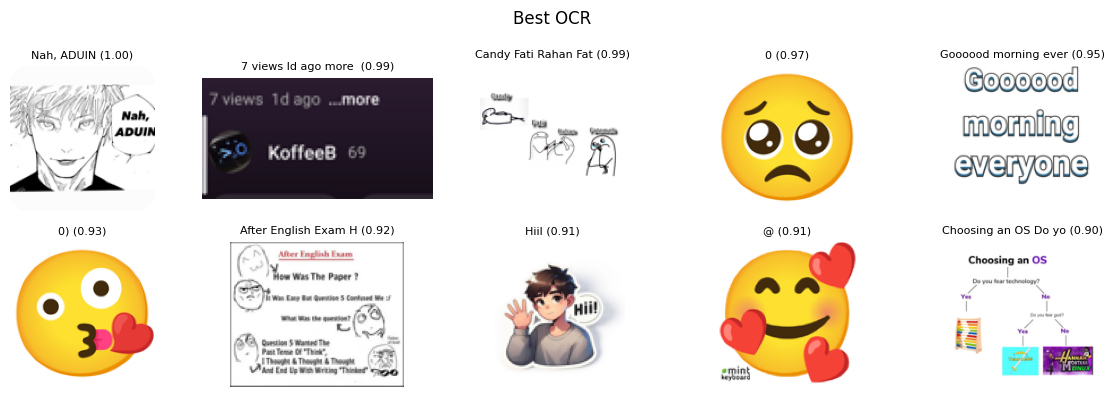

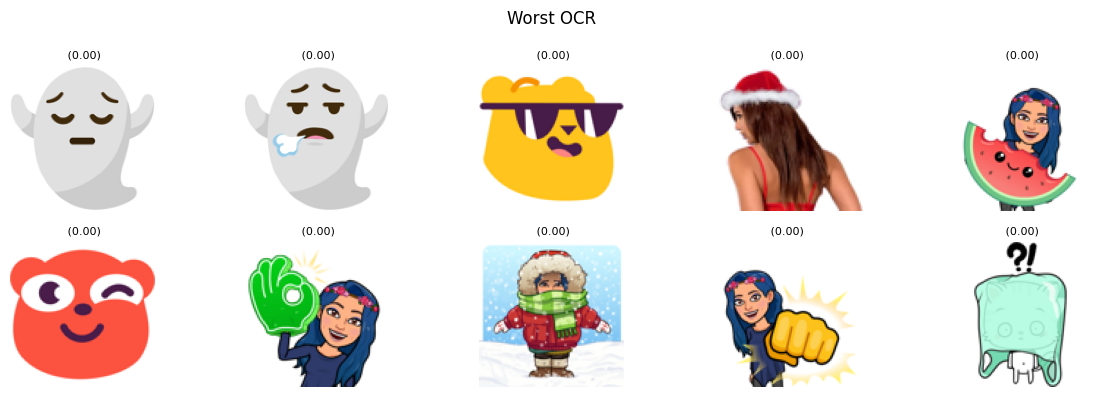

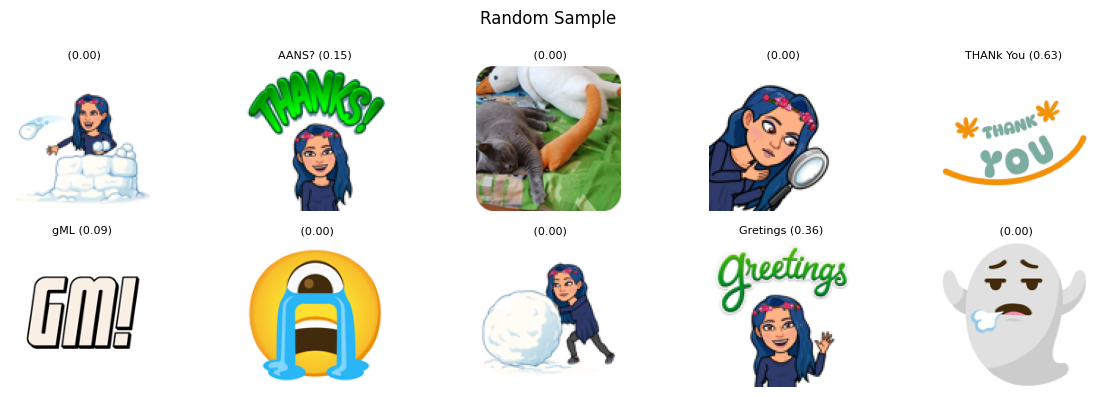

In [76]:
df_desc = df.sort_values("avg_conf", ascending=False)
df_asc = df.sort_values("avg_conf", ascending=True)
df_rnd = df.sample(frac=0.5).reset_index(drop=True)

def show_df_samples(cur_df, title):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    for i, (_, row) in enumerate(cur_df.iloc[:10].iterrows()):
        img = Image.open(row["path"])
        img = rgba_to_white_bg(img)
        img = img.resize((img.width // 4, img.height // 4))

        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{row['text'][:20]} ({row['avg_conf']:.2f})", fontsize=8)

    plt.tight_layout()
    plt.show()

show_df_samples(df_desc, "Best OCR")
show_df_samples(df_asc, "Worst OCR")
show_df_samples(df_rnd, "Random Sample")

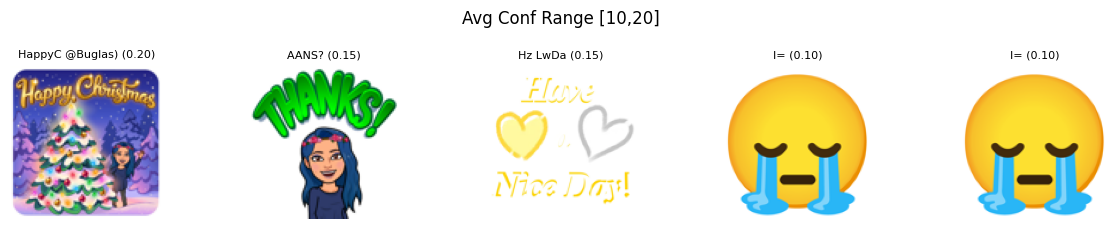

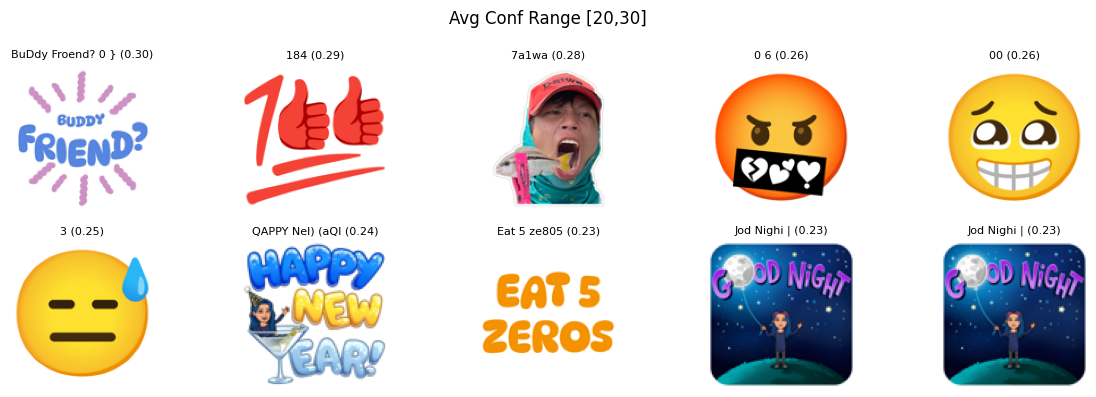

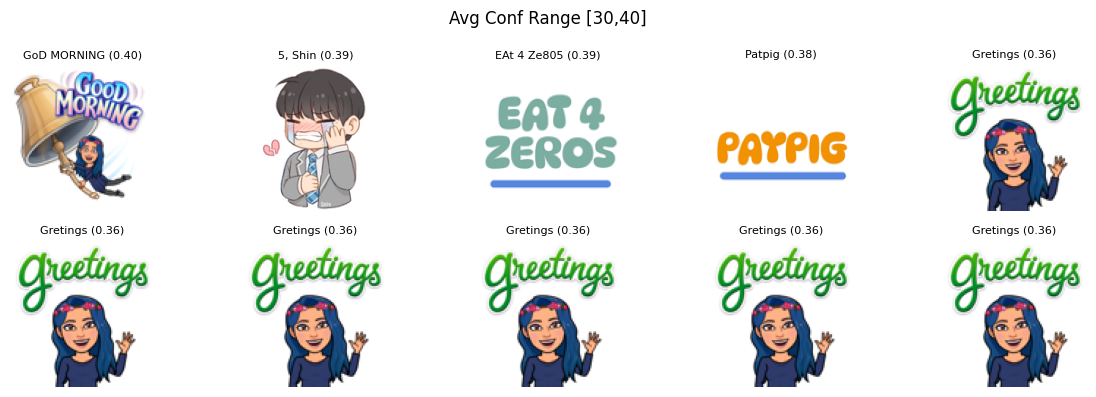

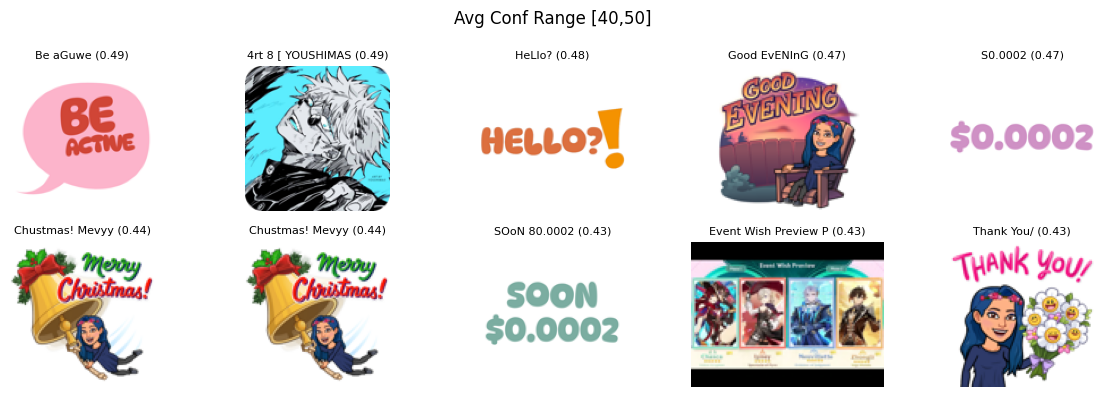

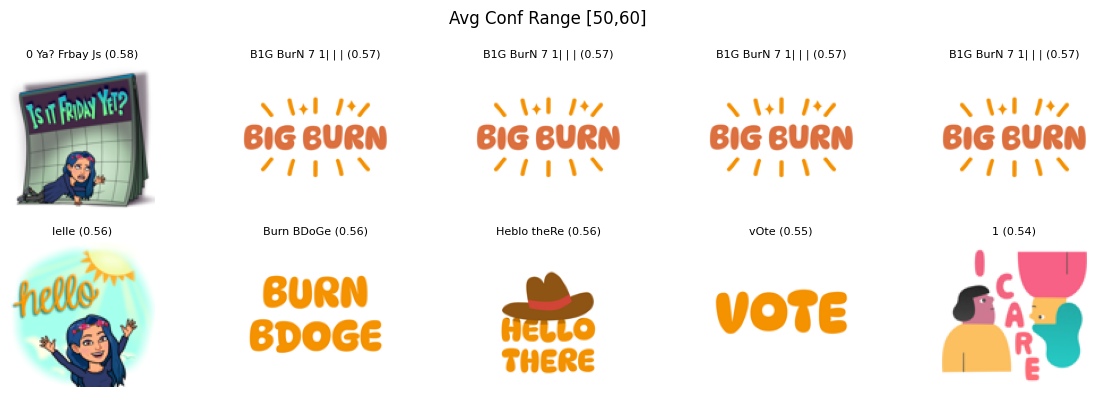

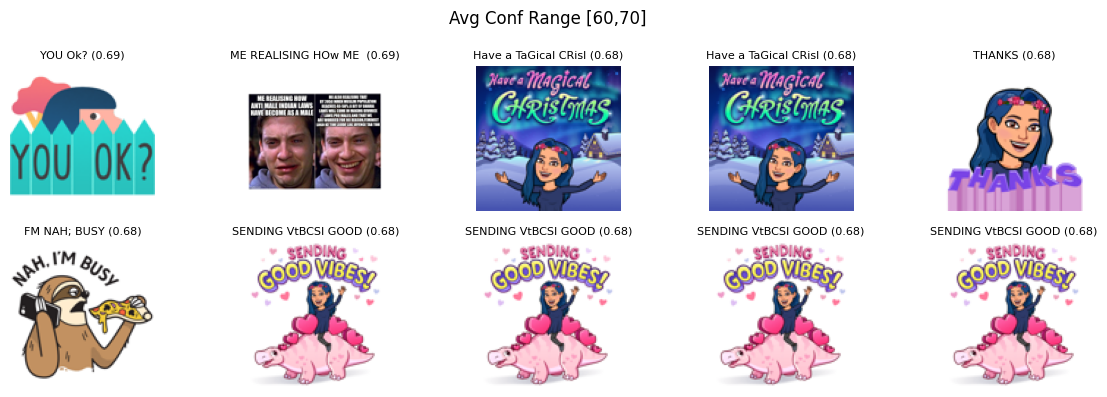

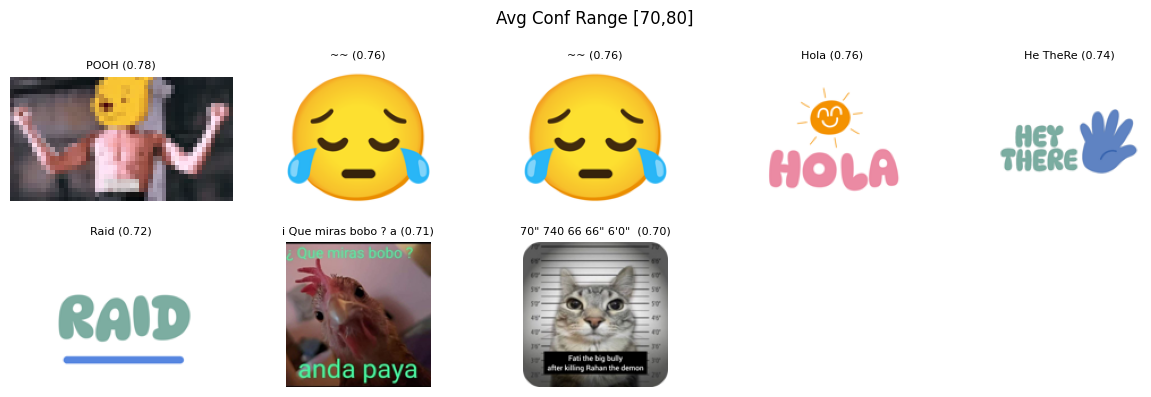

In [83]:
for i in range(7):
    lo = 10 + i*10
    hi = 10 + (i+1)*10
    df_range = df[(df["avg_conf"] * 100 > lo) & (df["avg_conf"] * 100 <= hi)]
    show_df_samples(df_range, f"Avg Conf Range [{lo:.0f},{hi:.0f}]")

In [12]:
rows = ocr(n=1000)
df = pd.DataFrame(rows)
df.head()

 12%|█▏        | 999/8295 [01:06<08:03, 15.08it/s]


,path,text,has_text,n_tokens,avg_conf
0,../data/sticker_suggest/5764992584032194316.png,0,True,1,0.971994
1,../data/sticker_suggest/6161133008473560502.png,~~,True,2,0.764959
2,../data/sticker_suggest/5395511541288155738.png,DON'T know,True,10,0.415496
3,../data/sticker_suggest/6192739380747044576.png,I=,True,2,0.102852
4,../data/sticker_suggest/6012839461463790656.png,,False,0,0.000000


In [ ]:
total = len(df)
with_text = df[df["n_tokens"]].sum()
share = with_text / total

print(f"Total images: {total}")
print(f"Images with text: {with_text}")
print(f"Share with text: {share:.2%}")

<Axes: >

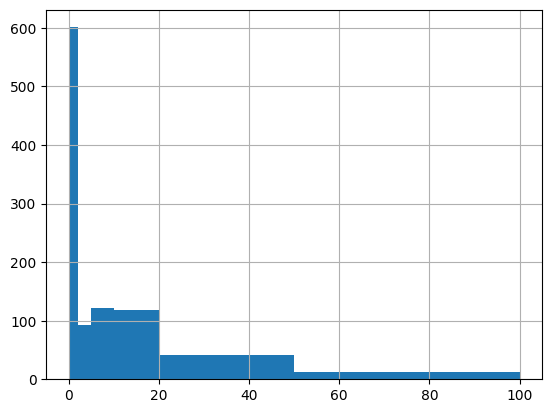

In [18]:
df["n_tokens"].hist(bins=[0, 2, 5, 10, 20, 50, 100])

<Axes: >

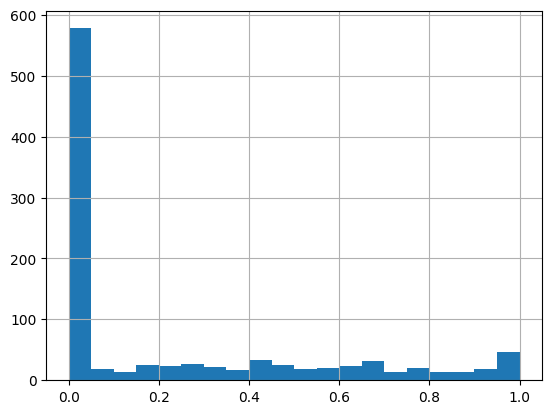

In [19]:
df["avg_conf"].hist(bins=20)

In [8]:
device = "cpu"
model.to(device)

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1024,), eps=1e-05, elementwi

In [1]:
import warnings
import torch
import open_clip
from PIL import Image
import os
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", message=".*pin_memory.*")

DATA_DIR = "../data/sticker_suggest/"

def filepath(filename):
    return os.path.join(DATA_DIR, filename)

image_paths = [filepath(f) for f in os.listdir(DATA_DIR)]

device = "cpu"

model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14", pretrained="openai")
tokenizer = open_clip.get_tokenizer("ViT-L-14")

model.to(device)

/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1024,), eps=1e-05, elementwi

In [2]:
import numpy as np
import torch
from tqdm import tqdm
import easyocr
from PIL import Image

reader = easyocr.Reader(['en'])

N = len(image_paths)
emb_size = 768

ocr_embeddings = np.zeros((N, emb_size), dtype=np.float32)
ocr_confidences = np.zeros(N, dtype=np.float32)

texts = [""] * N

def load_image_safe(path):
    try:
        img = Image.open(path)

        if path.lower().endswith(".gif"):
            img.seek(0)

        return img.convert("RGB")

    except:
        return None

for i, path in enumerate(tqdm(image_paths)):
    try:
        img = load_image_safe(path)

        if img is None:
            result = None
        else:
            result = reader.readtext(np.array(img))

        if result:
            words = [r[1] for r in result]
            scores = [r[2] for r in result]

            text = " ".join(words).strip()[:100]
            conf = sum(scores) / len(scores)
            n_tokens = len(text)
        else:
            text, conf, n_tokens = "", 0, 0

    except:
        text, conf, n_tokens = "", 0, 0

    if n_tokens > 1 and conf > 0.3:
        texts[i] = text
        ocr_confidences[i] = conf
    else:
        texts[i] = ""

valid_idx = [i for i, t in enumerate(texts) if t != ""]

batch_size = 128

for i in tqdm(range(0, len(valid_idx), batch_size)):
    batch_idx = valid_idx[i:i+batch_size]
    batch_texts = [texts[j] for j in batch_idx]

    tokens = tokenizer(batch_texts).to("cpu")

    with torch.no_grad():
        emb = model.encode_text(tokens)
        emb /= emb.norm(dim=-1, keepdim=True)

    emb = emb.numpy()

    for j, idx in enumerate(batch_idx):
        ocr_embeddings[idx] = emb[j]

np.save("../data/ocr_embeddings.npy", ocr_embeddings)
np.save("../data/ocr_confidences.npy", ocr_confidences)

100%|██████████| 16/16 [00:11<00:00,  1.38it/s]


In [3]:
image_embeddings = torch.tensor(np.load("../data/image_embeddings.npy")).to(device)
ocr_embeddings = torch.tensor(np.load("../data/ocr_embeddings.npy")).to(device)
ocr_confidences = torch.tensor(np.load("../data/ocr_confidences.npy"), dtype=torch.float32).to(device)
image_paths = np.load("../data/image_paths.npy")

In [35]:
def search(query, top_k=5):
    text = tokenizer([query]).to(device)

    with torch.no_grad():
        q_emb = model.encode_text(text)
        q_emb /= q_emb.norm(dim=-1, keepdim=True)

    image_scores = (q_emb @ image_embeddings.T).squeeze(0)
    ocr_scores = (q_emb @ ocr_embeddings.T).squeeze(0)
    
    # normalize scores
    image_scores = (image_scores - image_scores.mean()) / image_scores.std()
    ocr_scores = (ocr_scores - ocr_scores.mean()) / ocr_scores.std()

    alpha = 0.5
    scores = image_scores + alpha * (ocr_confidences ** 2) * ocr_scores

    top_idx = scores.topk(top_k).indices

    return [(image_paths[i], scores[i].item(), image_scores[i].item(), ocr_scores[i].item()) for i in top_idx]

In [26]:
def show_results(results):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    for i, (path, score, image_score, ocr_score) in enumerate(results):
        img = Image.open(path)
        plt.subplot(1, len(results), i + 1)
        plt.imshow(img)
        plt.title(f"{score:.2f} {image_score:.2f} {ocr_score:.2f}")
        plt.axis("off")

    plt.show()

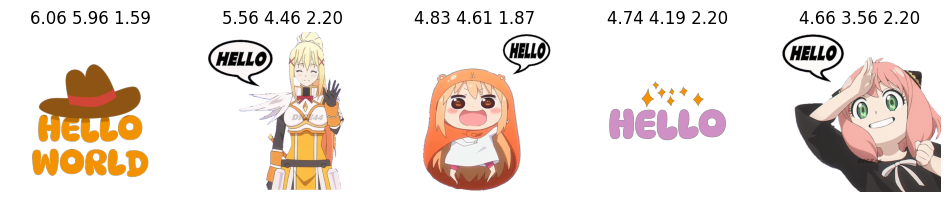

In [36]:
results = search("hello world")
show_results(results)

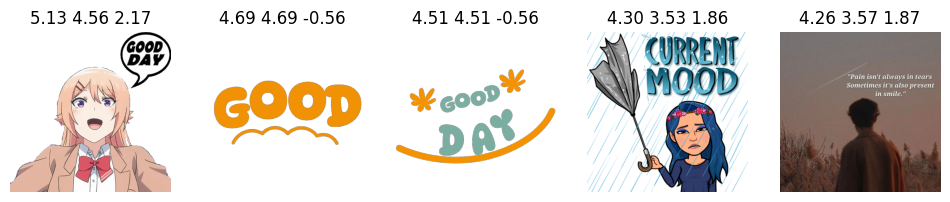

In [37]:
results = search("it's a good day, but also a sad one")
show_results(results)

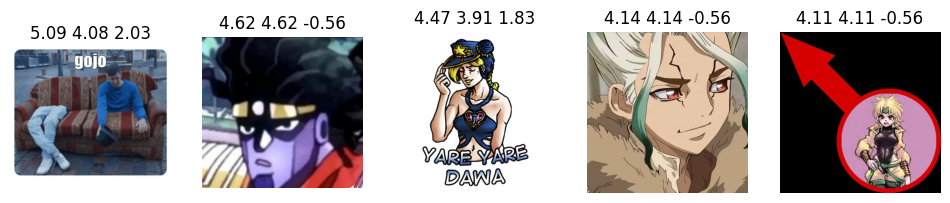

In [52]:
results = search("jojo")
show_results(results)